In [7]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


## Predicting Freight Cost

**Objective:** Predict the freight cost for a vendor invoice using features such as **quantity** and **invoice amount (dollars)** to improve cost forecasting, budgeting, and vendor negotiations.

* Freight is a significant component of the total landed cost of goods.
* Poor freight cost estimates can distort profit margins, budgeting, and inventory planning.
* An automated freight cost prediction system helps procurement teams estimate transportation costs before invoice arrival, enabling better financial planning and informed purchasing decisions.


In [8]:
conn = sqlite3.connect('../data/inventory.db')
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [9]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [10]:
for table in tables['name']:
    print ('Table name', table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [11]:
vendor_df = pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [12]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


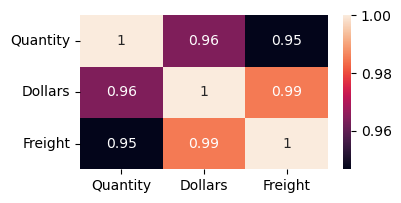

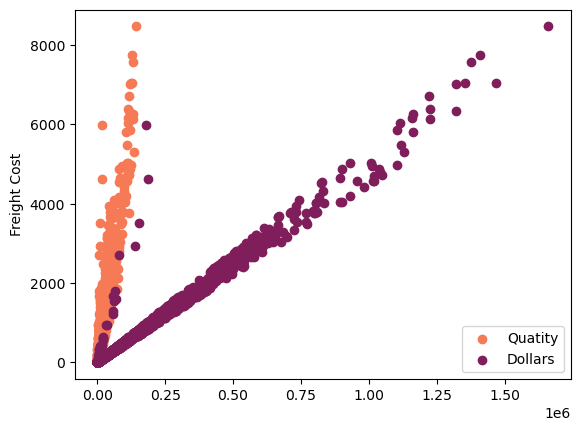

In [13]:
#relationship between Quantity, Dollars and freight

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(),annot =True)
plt.show()

plt.scatter(vendor_df['Quantity'],vendor_df['Freight'],color = '#f57a55')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'],color = '#7f1e5a')
plt.legend(['Quatity','Dollars'])
plt.ylabel('Freight Cost')
plt.show()


In [14]:
vendor_df['freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']

In [15]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [16]:
high_quantity

np.float64(5100.5)

In [17]:
low_quantity

np.float64(83.0)

In [20]:
vendor_df.loc[vendor_df['Quantity']>high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [22]:
vendor_df.loc[vendor_df['Quantity']<low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [98]:
X = vendor_df[['Dollars']]
y = vendor_df['Freight']

In [99]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [100]:
from sklearn.model_selection import train_test_split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [102]:
X_test

,Dollars
4564,352.95
1616,225706.96
4861,634.11
230,987.34
2042,31768.74
...,...
3388,242.16
1321,846.99
1322,205379.19
3618,242967.77


In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [104]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

model2 = DecisionTreeRegressor(max_depth = 4, random_state = 42)
model2.fit(X_train, y_train)

model3 = RandomForestRegressor(max_depth = 4,random_state = 42)
model3.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    from sklearn.metrics import mean_squared_error, r2_score
    import numpy as np
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mae)
    r2 = r2_score(y_test, preds)*100

    print(f"\n{model_name} Performance:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R^2 : {r2:.2f}%")

In [106]:
evaluate_model(model1, X_test, y_test, 'Linear Regresion')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regresion')
evaluate_model(model3, X_test, y_test, 'Random Forest Regresion')


Linear Regresion Performance:
MAE : 24.11
RMSE : 4.91
R^2 : 96.99%

Decision Tree Regresion Performance:
MAE : 38.12
RMSE : 6.17
R^2 : 96.30%

Random Forest Regresion Performance:
MAE : 30.31
RMSE : 5.51
R^2 : 96.69%


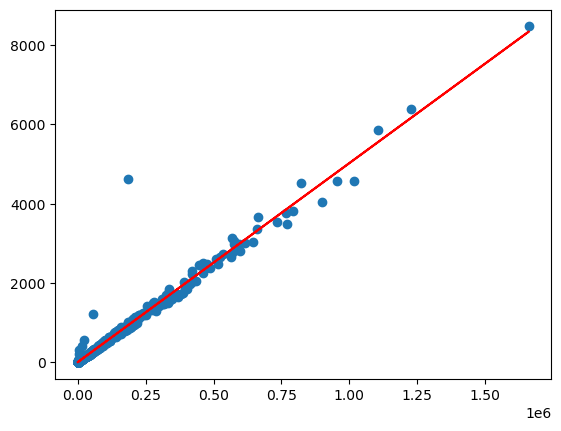

In [108]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model1.predict(X_test),color = 'red')

In [112]:
input_data = {
    "Dollars": [18500,9000],
   }
df = pd.DataFrame(input_data)

In [113]:
model1.predict(df)

array([97.78868161, 50.14455838])